# 12_时间序列分析方法-XGBoost

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 时间序列按先后顺序切分，修复随机切分后曲线与日期错位的问题。这是滚动一步预测：每个测试日使用当时已观测到的过去 7 天销量；不是一次性预测未来多天。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天聊聊时间序列，聊聊XGBoost\~

**时间序列**是按照时间顺序排列的一系列数据点。例如：

- 每天的股票价格。
- 每小时的气温。
- 每月的销售额。

时间序列的特点是数据点之间有**时间依赖性**，过去的数据可能会影响未来的数据。

**XGBoost**（eXtreme Gradient Boosting）是一个基于梯度提升算法的机器学习模型。它通过不断改进前面模型的预测误差，逐步建立一个强大的预测模型。XGBoost的优点包括：

1. 高效：计算速度快，性能强。
2. 灵活：可以处理分类和回归问题。
3. 精度高：在很多比赛中表现优异。

### 用XGBoost解决时间序列问题

虽然XGBoost本身不是专门为时间序列设计的，但我们可以通过适当的特征工程（比如利用过去的数据预测未来）来处理时间序列问题。

### 通俗的一个案例：预测超市的每日销售额

假设我们是一个超市的经理，想用前7天的销售额预测第8天的销售额。

#### 数据：

我们有过去10天的销售额数据：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
第1天：200元
第2天：220元
第3天：210元
第4天：230元
第5天：240元
第6天：250元
第7天：260元
第8天：270元
第9天：280元
第10天：290元
```

### 步骤1：构造特征和标签

我们用前7天的销售额作为特征，预测第8天的销售额（标签）。

| 特征1（第1天） | 特征2（第2天） | 特征3（第3天） | 特征4（第4天） | 特征5（第5天） | 特征6（第6天） | 特征7（第7天） | 标签（第8天） |
|-|-|-|-|-|-|-|-|
| 200 | 220 | 210 | 230 | 240 | 250 | 260 | 270 |
| 220 | 210 | 230 | 240 | 250 | 260 | 270 | 280 |
| 210 | 230 | 240 | 250 | 260 | 270 | 280 | 290 |

### 步骤2：训练模型

我们把数据输入XGBoost模型，进行训练。

XGBoost会尝试找到一个公式，把特征和标签的关系表达出来，比如：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
预测值 = 0.8 * 特征7 + 0.1 * 特征6 + 0.05 * 特征5
```

这只是一个例子，实际公式更复杂。

### 步骤3：预测

假设我们已经训练好了模型，现在我们用第4天到第10天的数据预测第11天的销售额：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
第4天：230元
第5天：240元
第6天：250元
第7天：260元
第8天：270元
第9天：280元
第10天：290元
```

模型预测：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
预测值 = 0.8 * 290 + 0.1 * 280 + 0.05 * 270 = 288.5元
```

## 公式解析

要结合时间序列和XGBoost进行预测，我们需要明确以下内容：

1. **时间序列的特征工程**：如何将时间序列问题转化为监督学习问题。
2. **XGBoost的数学原理**：梯度提升决策树的优化过程及公式推导。
3. **结合时间序列与XGBoost**：如何通过特征构造和模型训练实现时间序列预测。

### 一、时间序列特征工程

时间序列数据本质上是有序的，可以通过滑动窗口的方法构造特征和标签：

#### 给定时间序列数据 $\{y_1, y_2, \dots, y_T\}$：

- 特征：前 $n$个时间点的值 $\{y_{t-n}, \dots, y_{t-1}\}$。
- 标签：第 $t$个时间点的值 $y_t$。

构造监督学习的特征矩阵 $X$和标签向量 $y$：


$$
X = \begin{bmatrix}y_1 & y_2 & \cdots & y_{n} \\y_2 & y_3 & \cdots & y_{n+1} \\\vdots & \vdots & \cdots & \vdots \\y_{T-n} & y_{T-n+1} & \cdots & y_{T-1}\end{bmatrix},\quad y = \begin{bmatrix}y_{n+1} \\y_{n+2} \\\vdots \\y_T\end{bmatrix}
$$


#### 目标：

学习一个映射函数 $f$：


$$
y_t = f(y_{t-n}, y_{t-n+1}, \dots, y_{t-1}) + \epsilon
$$


其中 $\epsilon$是误差项。

### 二、XGBoost的数学原理

XGBoost是一种基于梯度提升的决策树方法，其目标是最小化损失函数。

#### 1. 损失函数

给定训练数据 $\{(x_i, y_i)\}_{i=1}^N$，模型的目标是最小化以下损失函数：


$$
L = \sum_{i=1}^N \ell(y_i, \hat{y}_i) + \sum_{k=1}^K \Omega(f_k)
$$


其中：

- $\ell(y_i, \hat{y}_i)$是预测值 $\hat{y}_i$和真实值 $y_i$之间的损失（如平方误差）。
- $\Omega(f_k)$是正则化项，用于控制模型复杂度。

#### 2. 模型的加法形式

XGBoost的预测是通过 $K$个基学习器的加和实现的：


$$
\hat{y}_i^{(t)} = \sum_{k=1}^t f_k(x_i), \quad f_k \in \mathcal{F}
$$


其中 $\mathcal{F}$是树模型的函数空间。

#### 3. 二阶泰勒展开

为了优化目标函数，XGBoost采用二阶泰勒展开：


$$
L^{(t)} = \sum_{i=1}^N \left[ \ell(y_i, \hat{y}_i^{(t-1)}) + g_i f_t(x_i) + \frac{1}{2} h_i f_t^2(x_i) \right] + \Omega(f_t)
$$


其中：

- $g_i = \frac{\partial \ell(y_i, \hat{y}_i)}{\partial \hat{y}_i}$是一阶梯度。
- $h_i = \frac{\partial^2 \ell(y_i, \hat{y}_i)}{\partial \hat{y}_i^2}$是二阶梯度。

#### 4. 优化目标

将损失函数的二阶展开式代入后，优化目标变为：


$$
\tilde{L}^{(t)} = \sum_{i=1}^N \left[ g_i f_t(x_i) + \frac{1}{2} h_i f_t^2(x_i) \right] + \Omega(f_t)
$$


#### 5. 树结构的优化

假设树模型的结构为 $q(x)$，表示每个样本 $x$被分配到的叶子节点索引。每个叶子节点 $j$的权重为 $w_j$。则：


$$
f_t(x) = w_{q(x)}, \quad \Omega(f_t) = \gamma T + \frac{1}{2} \lambda \sum_{j=1}^T w_j^2
$$


其中 $T$是叶子节点数，$\gamma$和 $\lambda$是正则化参数。

优化目标变为：


$$
\tilde{L}^{(t)} = \sum_{j=1}^T \left[ G_j w_j + \frac{1}{2} (H_j + \lambda) w_j^2 \right] + \gamma T
$$


其中：

- $G_j = \sum_{i \in I_j} g_i$是叶子节点 $j$的梯度和。
- $H_j = \sum_{i \in I_j} h_i$是叶子节点 $j$的二阶梯度和。

对 $w_j$求导并令其为 0，得到最优叶子节点权重：


$$
w_j^* = -\frac{G_j}{H_j + \lambda}
$$


将 $w_j^*$代入优化目标，得到最佳分裂增益：


$$
\text{Gain} = \frac{1}{2} \left[ \frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} - \frac{(G_L + G_R)^2}{H_L + H_R + \lambda} \right] - \gamma
$$


### 三、结合时间序列与XGBoost

#### 1. 特征工程

将时间序列数据转化为特征矩阵 $X$和标签 $y$，如前述所述。

#### 2. 模型训练

使用XGBoost优化目标函数，通过构造决策树逐步拟合数据的残差。

#### 3. 预测

训练完成后，输入新的时间序列特征，预测未来的值。

### 总结3点

- **时间序列问题**通过特征工程转化为监督学习问题，构造特征矩阵和标签。
- **XGBoost**通过梯度提升和二阶优化，构建多棵决策树，拟合残差以最小化损失。
- **结合方法**：将时间序列特征输入XGBoost，模型学习时间依赖性，实现高效预测。

公式推导的关键在于理解XGBoost的优化过程，以及如何将时间序列特征转换为适合模型训练的数据形式。

## 完整案例

我们选择**电商销售额预测**案例，结合历史销量和外部因素（如节假日）进行时间序列预测，使用XGBoost并绘制炫酷的分析图形。

以下代码实现了：

1. 数据生成与特征工程。
2. 使用XGBoost模型进行预测。
3. 数据分析可视化，包括特征重要性和预测结果的时间序列对比。

RMSE: 48.56


/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_11304/2533885261.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=feature_importance, palette="viridis")


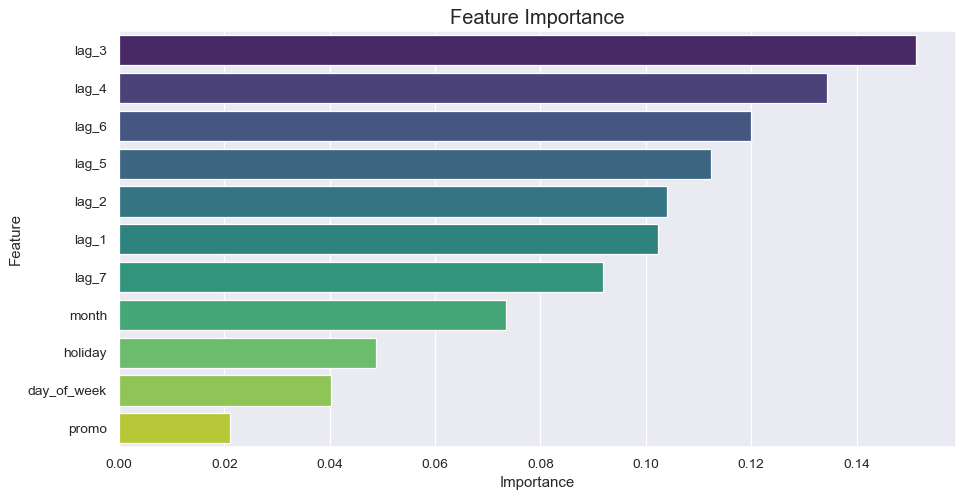

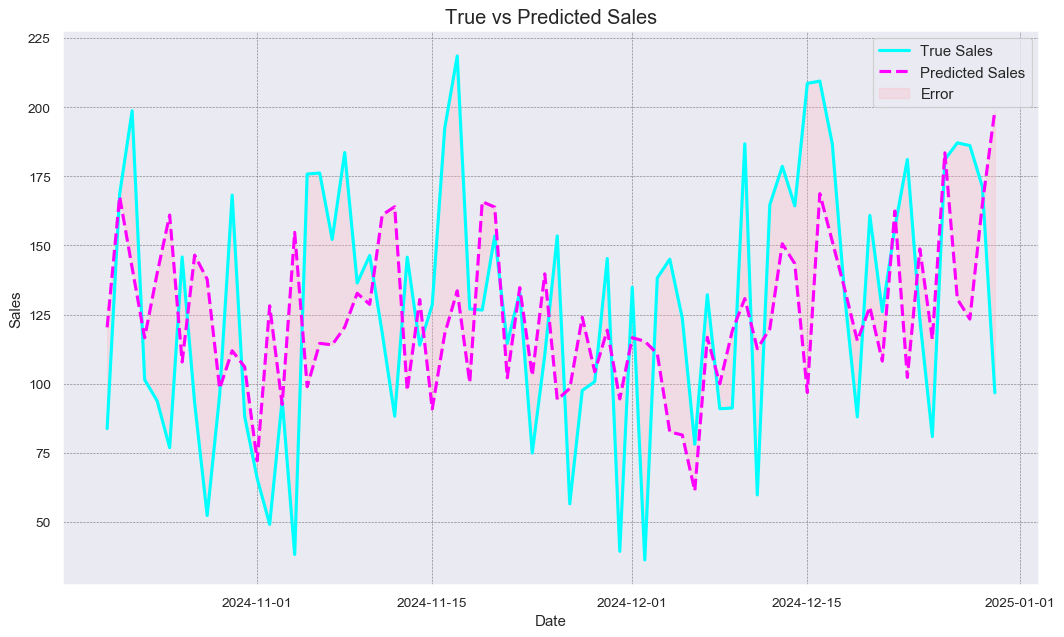

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 1. 数据生成
np.random.seed(42)
days = 365
date_range = pd.date_range(start="2024-01-01", periods=days)
sales = np.random.randint(50, 200, size=days) + np.sin(np.arange(days) / 5) * 20
holiday = [1 if d.day in [1, 15] else 0 for d in date_range]  # 模拟假日
promo = np.random.choice([0, 1], size=days, p=[0.8, 0.2])  # 随机促销活动

data = pd.DataFrame({
    "date": date_range,
    "sales": sales,
    "holiday": holiday,
    "promo": promo
})
data["day_of_week"] = data["date"].dt.dayofweek
data["month"] = data["date"].dt.month

# 滞后特征
for lag in range(1, 8):
    data[f"lag_{lag}"] = data["sales"].shift(lag)

# 删除空值行
data.dropna(inplace=True)

# 2. 特征与标签
X = data.drop(columns=["date", "sales"])
y = data["sales"]

# 数据集划分
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 3. 模型训练
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, n_jobs=1)
model.fit(X_train, y_train)

# 4. 模型预测
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.2f}")

# 5. 绘图
sns.set_theme(style="darkgrid")
plt.rcParams['font.sans-serif'] = CJK_FONTS
# (1) 特征重要性
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x="importance", y="feature", data=feature_importance, palette="viridis")
plt.title("Feature Importance", fontsize=16)
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.show()

# (2) 时间序列预测对比
plt.figure(figsize=(14, 8))
plt.plot(data["date"].iloc[-len(y_test):], y_test, label="True Sales", color="cyan", linewidth=2.5)
plt.plot(data["date"].iloc[-len(y_test):], y_pred, label="Predicted Sales", color="magenta", linestyle="--", linewidth=2.5)
plt.fill_between(data["date"].iloc[-len(y_test):], y_test, y_pred, color="lightpink", alpha=0.3, label="Error")
plt.title("True vs Predicted Sales", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Sales", fontsize=12)
plt.legend(fontsize=12)
plt.grid(color="gray", linestyle="--", linewidth=0.5)
plt.show()

1. **数据生成**：创建365天的时间序列数据，包含随机销售额、节假日标记、促销活动和滞后特征。
2. **特征工程**：构造滞后特征（过去7天的销售额），并加入时间特征（如星期、月份）。
3. **模型训练**：使用XGBoost进行回归预测，评估模型性能（RMSE）。

**特征重要性图**：显示哪些特征对预测最重要。

![原文参考图，当前结果见代码输出](attachments/img_037.png)

**时间序列对比图**：展示真实销售额和预测销售额的时间序列趋势，突出误差区域。

![原文参考图，当前结果见代码输出](attachments/img_038.png)

整个内容，清晰展示XGBoost在时间序列预测中的表现。

## 优缺点和适用场景

### 优点

1. **高性能**：

   - XGBoost在处理大规模数据时速度快，内存效率高。
   - 支持并行化和分布式计算，适合处理复杂时间序列数据。
2. **灵活性**：

   - 可以处理非线性关系，适用于复杂的时间序列问题。
   - 支持自定义损失函数，能够适配特定需求。
3. **无需严格的假设**：

   - 传统时间序列方法（如ARIMA）要求数据满足平稳性，而XGBoost无需这种严格假设。
4. **强大的特征工程能力**：

   - 可以结合外部特征（如节假日、天气等）提升预测精度。
   - 自动处理缺失值，减少数据清理工作量。
5. **鲁棒性**：

   - 对异常值和噪声数据的处理能力较强。

### 缺点

1. **时间依赖建模不足**：

   - XGBoost本质是回归模型，不能直接捕捉时间序列的长期依赖性。
   - 对于强时间依赖的序列（如周期性、趋势性），需要额外特征工程。
2. **对数据序列长度敏感**：

   - 短时间序列可能无法提供足够的特征，影响模型性能。
3. **模型解释性较弱**：

   - 决策树模型的预测结果较难直观解释，与统计模型（如ARIMA）相比不够透明。
4. **需要额外特征工程**：

   - 需要手动构造滞后特征、滑动窗口等，这增加了建模复杂度。

### 适用场景

1. **非平稳时间序列**：

   - 数据波动较大或有明显的非线性关系，传统模型无法处理时。
   - 例如：电商销售额、股票市场价格。
2. **多特征时间序列**：

   - 除时间序列本身，还涉及其他相关变量（如天气、事件等）。
   - 例如：商品销量预测（结合天气、促销信息）。
3. **长时间跨度预测**：

   - 需要预测多个未来时间点的值。
   - 例如：未来一周的用电需求预测。
4. **大规模数据**：

   - 数据量大、维度多，传统方法计算效率不足时。
   - 例如：IoT设备的传感器数据预测。

#### 不适合场景：

1. **极短时间序列**：数据量不足，难以训练模型。
2. **强时间依赖性**：数据具有明显的周期性和趋势性，且缺乏额外特征辅助时（如ARIMA更适用）。

## 最后

XGBoost 在时间序列建模里挺有分量，它能很好地处理非线性关系，比传统线性方法更灵活。它在特征工程结合滞后变量和滚动统计时表现特别强，可以捕捉复杂的时序模式。很多时候它在预测精度上能超越 ARIMA 之类的经典模型，尤其在数据量大、特征多的情况下更显优势。因为它有内置的正则化机制，所以对过拟合的控制也比较稳。整体来说，它已经成为时间序列预测里很常见、很实用的一个模型。